# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (26 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.6 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl (178.7 MB)
Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl (1.8 MB)
Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp3

/srv/conda/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


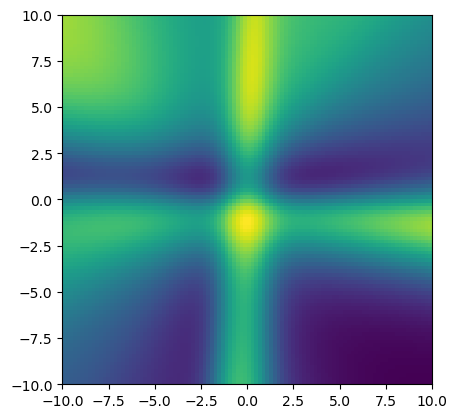

In [2]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
import data
import matplotlib.pyplot as plt
import torch

model = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [3]:
# Artificial Intelligence - The overview term, it is anything that resembles human intelligence
# Machine Learning - A subset of artificial intelligence, computers that learn from data
# Deep Learning - A subset of machine learning, based on neural networks to get higher performing data

What is a neural network?

In [4]:
# a neural network is a computational model based on the brain with nodes that learn from data and make decisions or predicitons.

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [5]:
# The number 2 is the input number and is the size of the input number while 50 represents the size of each output sample.

What does the activation function do?

In [6]:
# Activation functions help models learn as they decide whether a neuron should be activated which makes the output nonlinear.

What is a loss function? Why do we need one?

In [7]:
# A loss function calculates the error the model has when predicting. It helps to have one to improve them model to be more accurate.

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [8]:
# optimizer.zero_grad() needs to be called first because it erases any previous gradients from the model from being used, only the new ones. Then loss.backward() is called because it computes the new gradient of the model with respect to the new parameters.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

Iteration 0, Loss: 1.0311156511306763
Iteration 100, Loss: 1.0311156511306763
Iteration 200, Loss: 1.0311156511306763
Iteration 300, Loss: 1.0311156511306763
Iteration 400, Loss: 1.0311156511306763
Iteration 500, Loss: 1.0311156511306763
Iteration 600, Loss: 1.0311156511306763
Iteration 700, Loss: 1.0311156511306763
Iteration 800, Loss: 1.0311156511306763
Iteration 900, Loss: 1.0311156511306763


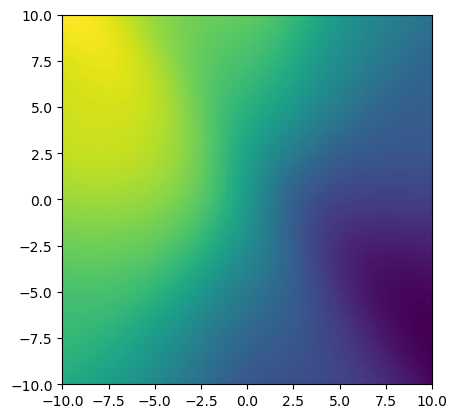

In [9]:
#model = torch.nn.Sequential(
    #torch.nn.Linear(2,50),
    #torch.nn.Sigmoid(),
    #torch.nn.Linear(50,1))
#original

model2 = torch.nn.Sequential( #new model with 30 neurons rather than 50
    torch.nn.Linear(2,30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(1000):
    y_pred = model2(data.x)
    loss = loss_fn(y_pred,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model2(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()
# modified

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [10]:
# When the code runs with 30 neurons it has a worse interpretation of the data than when it runs with 50 neurons. The 30 neuron code is returning a loss of above 1 and the 50 neuron code returns a loss of less than 1.

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

Iteration 0, Loss: 1.3803733587265015
Iteration 100, Loss: 1.3803733587265015
Iteration 200, Loss: 1.3803733587265015
Iteration 300, Loss: 1.3803733587265015
Iteration 400, Loss: 1.3803733587265015
Iteration 500, Loss: 1.3803733587265015
Iteration 600, Loss: 1.3803733587265015
Iteration 700, Loss: 1.3803733587265015
Iteration 800, Loss: 1.3803733587265015
Iteration 900, Loss: 1.3803733587265015


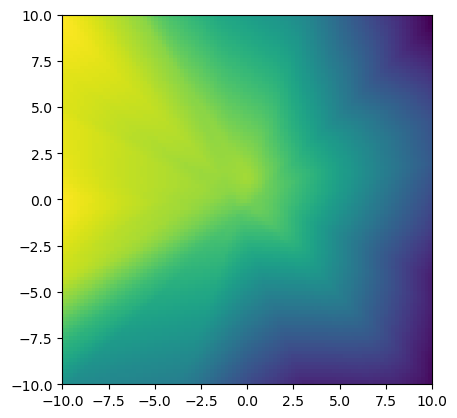

In [11]:
model3 = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.ReLU(),
    torch.nn.Linear(50,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(1000):
    y_pred = model3(data.x)
    loss = loss_fn(y_pred,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model3(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()

# when changin torch.nn.Sigmoid to torch.nn.ReLU the loss function increases dramatically, even more than when it ran with only 30 neurons.

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

Iteration 0, Loss: 1.354967474937439
Iteration 100, Loss: 0.8233667612075806
Iteration 200, Loss: 0.6010004878044128
Iteration 300, Loss: 0.41272905468940735
Iteration 400, Loss: 0.3260177671909332
Iteration 500, Loss: 0.2745250463485718
Iteration 600, Loss: 0.23243829607963562
Iteration 700, Loss: 0.20404590666294098
Iteration 800, Loss: 0.17989271879196167
Iteration 900, Loss: 0.15931609272956848


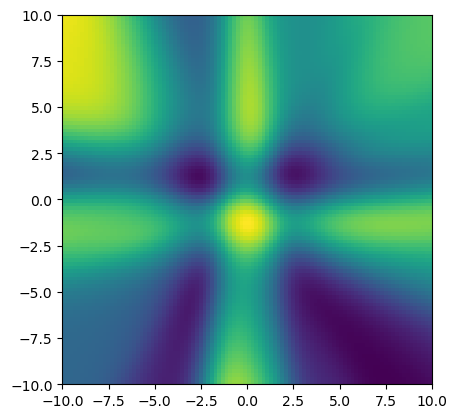

In [12]:
model = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.Tanh(),
    torch.nn.Linear(50,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()

# when changing from Sigmoid to Tanh the loss function decreases dramatically and returns a much better representation of the data.

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [13]:
# Sigmoid returns a logistic curve between 0 and 1. ReLU returns a linear function that outputs only positive numbers. Tanh returns a logistic curve centered at 0 between -1 and 1. 

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

Iteration 0, Loss: 1.1690784692764282
Iteration 100, Loss: 0.44827184081077576
Iteration 200, Loss: 0.2353886514902115
Iteration 300, Loss: 0.16231344640254974
Iteration 400, Loss: 0.11545313894748688
Iteration 500, Loss: 0.09011836349964142
Iteration 600, Loss: 0.07981196790933609
Iteration 700, Loss: 0.07427847385406494
Iteration 800, Loss: 0.07085663080215454
Iteration 900, Loss: 0.06837364286184311


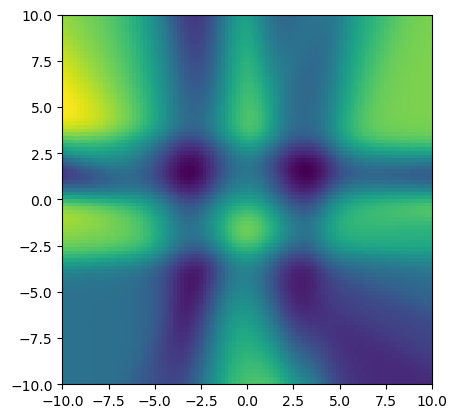

In [14]:
model = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()
# when changing the learning rate the loss functions at the 1000th iteration are very different with the original being around 0.24 and this new iteration being 0.07 which is much lower making this more accurate to the hidden data.

Modify your model to have **two hidden layers** instead of one. Give that code here.

Iteration 0, Loss: 1.3211054801940918
Iteration 100, Loss: 0.8447083234786987
Iteration 200, Loss: 0.6028803586959839
Iteration 300, Loss: 0.41048529744148254
Iteration 400, Loss: 0.3211717903614044
Iteration 500, Loss: 0.2648095190525055
Iteration 600, Loss: 0.22815656661987305
Iteration 700, Loss: 0.1847386509180069
Iteration 800, Loss: 0.1477280557155609
Iteration 900, Loss: 0.12267985939979553


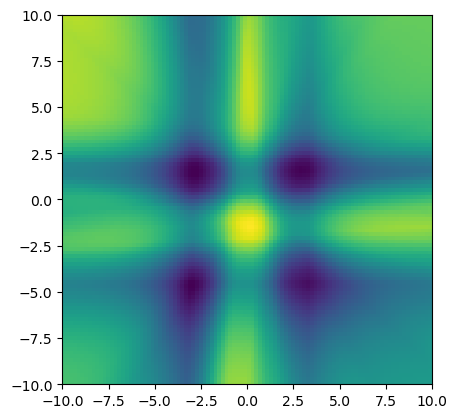

In [15]:
model = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.ReLU(),
    torch.nn.Tanh(),
    torch.nn.Linear(50,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [16]:
import new_data

Define a new model and train it **poorly** in the cell below.

Iteration 0, Loss: 729.1507568359375
Iteration 100, Loss: 631.398681640625
Iteration 200, Loss: 546.44677734375
Iteration 300, Loss: 475.0814514160156
Iteration 400, Loss: 419.0242614746094
Iteration 500, Loss: 379.4195251464844
Iteration 600, Loss: 356.23321533203125
Iteration 700, Loss: 343.4919128417969
Iteration 800, Loss: 336.4045715332031
Iteration 900, Loss: 331.9217224121094


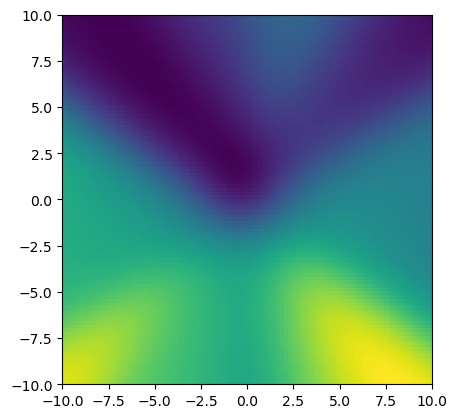

In [17]:
model = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(1000):
    y_pred = model(new_data.x)
    loss = loss_fn(y_pred,new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Iteration 0, Loss: 704.4121704101562
Iteration 100, Loss: 122.86701202392578
Iteration 200, Loss: 33.341278076171875
Iteration 300, Loss: 13.983057022094727
Iteration 400, Loss: 7.251182556152344
Iteration 500, Loss: 4.4051513671875
Iteration 600, Loss: 2.7280330657958984
Iteration 700, Loss: 1.8918389081954956
Iteration 800, Loss: 1.3535857200622559
Iteration 900, Loss: 1.0046892166137695


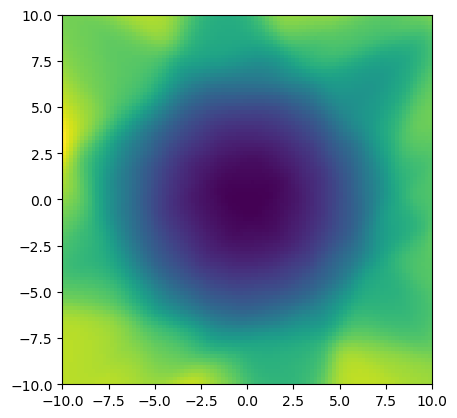

In [24]:
model = torch.nn.Sequential(
    torch.nn.Linear(2,100),
    torch.nn.Tanh(),
    torch.nn.Sigmoid(),
    torch.nn.Linear(100,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-1)

for t in range(1000):
    y_pred2 = model(new_data.x)
    loss = loss_fn(y_pred2,new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid2 = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model(grid2).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

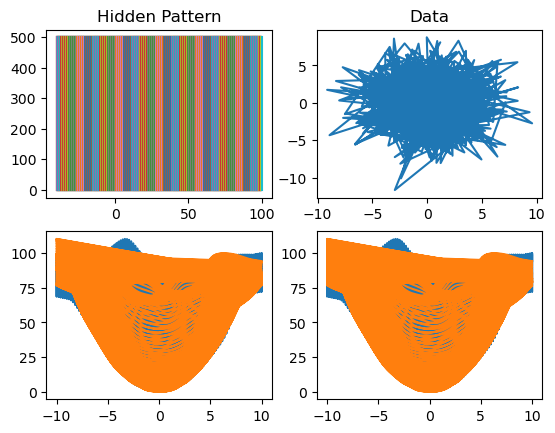

In [29]:

grid_flattened = grid.reshape(-1, 2) 
y_pred_flattened = y_pred.reshape(-1, 1)  

model.eval()  
with torch.no_grad():  
    y_pred_flattened = model(grid_flattened).detach().numpy()


grid_flattened2 = grid2.reshape(-1, 2)
y_pred_flattened2 = y_pred2.reshape(-1, 1)  

model.eval()
with torch.no_grad():
    y_pred_flattened2 = model(grid_flattened2).detach().numpy()



plt.subplot(2,2,1)
plt.plot(new_data.X,new_data.Y)
plt.title('Hidden Pattern')

plt.subplot(2,2,2)
plt.plot(new_data.x_values,new_data.y_values)
plt.title('Data')

plt.subplot(2,2,3)
plt.plot(grid_flattened,y_pred_flattened)

plt.subplot(2,2,4)
plt.plot(grid_flattened2,y_pred_flattened2)



plt.show()

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [38]:
import csv
csv_file_path = 'variants.csv'
columns_to_extract = ['new_cases', 'percent_cases_sequenced']

new_cases=[]
percent_cases_sequenced=[]

with open(csv_file_path, mode='r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        new_cases.append(row['new_cases'])
        percent_cases_sequenced.append(row['percent_cases_sequenced'])

py_file_path = 'variants.py'
with open(py_file_path, mode='w') as file:
    file.write(f"# This file contains the data from {csv_file_path}\n\n")
    file.write(f"data = {data}")

import variants

model = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1))

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(1000):
    y_pred = model(variants.new_cases)
    loss = loss_fn(y_pred,variants.percent_cases_sequenced)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x,new_x)),dim=2)

output = model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show()




SyntaxError: invalid syntax (variants.py, line 3)

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!